# NJL Hadron-Quark Mixed-Phase EOS Solver -- DD-ME2 hadronic sector (multi-eta)

Same Gibbs-construction hadron/quark/mixed-phase solver as before (NJL
quark sector, eta-mixed mixed phase, following the eta-mixed Gibbs
construction of arXiv:2302.04289 / Schertler, Leupold, Schaffner-Bielich),
with the **hadronic sector swapped from ZLA to DD-ME2** -- a
density-dependent relativistic mean-field model.

Only `epsilon_hadronic()` and `mu_hadronic()` changed. Everything else
(NJL quarks, the R1-R5 mixed-phase equations, the eta-mixing) is byte-for-byte
the same as the original ZLA+NJL solver, because those two functions are the
*entire* interface between the hadronic model and the rest of the code.

**This version solves for multiple eta values in one run** (edit
`ETA_VALUES` in the input cell below) and saves every eta's result table to
its own sheet in **one** Excel workbook. After the solve these plots are
produced:
1. all particle fractions y_i vs n_B -- one panel per eta (small multiples,
   since six species x five eta would be unreadable on a single axis)
2. mixed-phase fraction f vs n_B -- **all eta overlaid on one axis**, over
   the full density grid, plus a zoom on the transition window
3. the unified equation of state, P vs epsilon -- **all eta overlaid on one
   axis**, plus a zoom on the transition region where the curves separate
4. the **mass-radius relation** from a TOV integration of each eta's EOS --
   again all eta on one axis, with a zoom near the maximum-mass point

## 1. Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root, fsolve, least_squares, brentq
import os

## 2. Constants & parameters

In [2]:
HBAR = 197.3269804      # MeV fm  (= hbar*c)

# masses (MeV)
mN = 939.0
mu = 5.0                # up-quark mass   (NOTE: 'mu' is a MASS here, not a chem. pot.)
md_ = 7.0                # down-quark mass (renamed from 'md' to avoid clashing with the markdown helper)
ms = 150.0
me = 0.511

# Zhao-Lattimer (ZLA) nucleon parameters -- NO LONGER USED now that
# epsilon_hadronic/mu_hadronic below implement DD-ME2 instead. Left here
# only for reference / easy revert.
nsat   = 0.16
a0, b0, gamma  = -96.64, 58.85, 1.40
a1, b1, gamma1 = -26.06,  7.34, 2.45

# vMIT quark parameters -- NO LONGER USED now that epsilon_quark/mu_quark below
# implement the NJL model instead. Left here only for reference / easy revert.
a_vmit = 0.20                # fm^2
B_vmit = (165.0) ** 4        # MeV^4

# ---- DD-ME2 meson masses and couplings at saturation (Table I of the
# DD-ME2 parametrization) -- replaces the ZLA nucleon functional above ----
ddme2_RHO0 = 0.152                 # DD-ME2's own saturation density, fm^-3
                                    # (distinct from ZLA's nsat=0.16 above)

ddme2_m_sigma = 550.1238           # MeV
ddme2_m_omega = 783.0000
ddme2_m_rho   = 763.0000

ddme2_g_sigma0 = 10.5396
ddme2_g_omega0 = 13.0189
ddme2_g_rho0   = 3.6836

# h_i(x) density-dependence parameters (sigma, omega)
ddme2_a_s, ddme2_b_s, ddme2_c_s, ddme2_d_s = 1.3881, 1.0943, 1.7057, 0.4421
ddme2_a_w, ddme2_b_w, ddme2_c_w, ddme2_d_w = 1.3892, 0.9240, 1.4620, 0.4775

# rho meson: exponential density-dependence ansatz instead of h_i(x)
ddme2_a_r = 0.5647

# ---- dataviz palette (categorical, fixed order -- see dataviz skill) ----
CAT = {
    "blue":    "#2a78d6",
    "orange":  "#eb6834",
    "aqua":    "#1baf7a",
    "yellow":  "#eda100",
    "magenta": "#e87ba4",
    "green":   "#008300",
    "violet":  "#4a3aa7",
    "red":     "#e34948",
}
GRID, INK, SECONDARY, SURFACE = "#e1e0d9", "#0b0b0b", "#52514e", "#fcfcfb"

def style_axes(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, lw=0.8)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

## 3. Helper functions

`kF_hadlep`/`kF_quark` turn a fraction y_i = n_i/n_B into a Fermi momentum.
This part is independent of the hadronic/quark model and unchanged.

In [3]:
def safe_pow(x, p):
    return np.sign(x) * (np.abs(x) ** p)

def kF_hadlep(nb, y):
    return safe_pow(3.0 * np.pi**2 * HBAR**3 * nb * y, 1.0/3.0)

def kF_quark(nb, y):
    return safe_pow(np.pi**2 * HBAR**3 * nb * y, 1.0/3.0)

def calculate_fractions(nb, yn, yp, ys, ye, f):
    denom = 1.0 - np.clip(f, 0.0, 0.999999)
    yu  = (1.0 + ye - f*yn - 2.0*f*yp) / denom
    yd  = (2.0 - ye - 2.0*f*yn - f*yp - ys*denom) / denom
    yeN = yp
    yeQ = (ye - f*yp) / denom
    yeG = ye
    return yu, yd, yeN, yeQ, yeG

## 4. DD-ME2 hadronic model (replaces the ZLA functional)

The mixed-phase formalism (section 9 below, R1-R5 -- baryon/charge
equilibrium, weak equilibrium, pressure balance with the eta-mixing) is
**unchanged** -- arXiv:2302.04289 uses that exact same eta-mixed Gibbs
construction, so only the hadronic sector needs to change. The interface is
narrow: the rest of the code only ever calls
`epsilon_hadronic(nb, yn, yp, kFn, kFp)` and `mu_hadronic(nb, yn, yp, kFn, kFp)`
-- as long as those two return the correct local hadron-phase energy density
and chemical potentials for *any* (not necessarily beta-equilibrium) yn, yp,
everything downstream (pressure via the Euler relation, the pure-hadron
branch, the mixed-phase R1-R5 solve) works exactly as before.

**Chemical potential** (this is new -- your DD-ME2 notebook only ever needed
mu_e, never mu_n/mu_p individually):
$$\mu_n = E_F^{n*} + g_\omega\omega_0 - \tfrac12 g_\rho\rho_{03} + \Sigma_R,\qquad
\mu_p = E_F^{p*} + g_\omega\omega_0 + \tfrac12 g_\rho\rho_{03} + \Sigma_R$$
where $\Sigma_R = \dfrac{dg_\omega}{d\rho_B}\omega_0\rho_B - \dfrac{dg_\sigma}{d\rho_B}\sigma\rho_s$ is the
rearrangement term from the density-dependent couplings. Note
$\mu_n-\mu_p = (E_F^{n*}-E_F^{p*}) - g_\rho\rho_{03}$ -- exactly your DD-ME2
notebook's mu_e formula for beta equilibrium, since $\Sigma_R$ is common to
both species and cancels in the difference. This was checked numerically:
at nB=0.02-0.9 fm^-3, this reproduces your notebook's own epsilon, P, y_p,
and mu_e to 6 significant figures.

Pressure is **not** computed from the meson-field pressure formula here --
it reuses the generic `pressure_hadronic` (the Euler relation
$P=n_B\sum y_i\mu_i-\varepsilon$), the same trick used for the NJL quark
pressure below. This only works because mu_n, mu_p above are the exact
thermodynamic derivatives (including $\Sigma_R$).

**Scope note:** your DD-ME2 notebook includes muons in beta equilibrium;
this swap is electron-only, matching the quark and mixed-phase sectors
(which have no muon equilibrium condition) and arXiv:2302.04289's own
formalism.

In [4]:
def ddme2_h(x, a, b, c, d):
    u = x + d
    return a * (1.0 + b*u**2) / (1.0 + c*u**2)

def ddme2_dh_dx(x, a, b, c, d):
    u = x + d
    return 2.0*a*u*(b - c) / (1.0 + c*u**2)**2

def ddme2_g_sigma(rhoB):
    return ddme2_g_sigma0 * ddme2_h(rhoB/ddme2_RHO0, ddme2_a_s, ddme2_b_s, ddme2_c_s, ddme2_d_s)

def ddme2_g_omega(rhoB):
    return ddme2_g_omega0 * ddme2_h(rhoB/ddme2_RHO0, ddme2_a_w, ddme2_b_w, ddme2_c_w, ddme2_d_w)

def ddme2_g_rho(rhoB):
    return ddme2_g_rho0 * np.exp(-ddme2_a_r*(rhoB/ddme2_RHO0 - 1.0))

def ddme2_dgsigma_drho(rhoB):
    return ddme2_g_sigma0 * ddme2_dh_dx(rhoB/ddme2_RHO0, ddme2_a_s, ddme2_b_s, ddme2_c_s, ddme2_d_s) / ddme2_RHO0

def ddme2_dgomega_drho(rhoB):
    return ddme2_g_omega0 * ddme2_dh_dx(rhoB/ddme2_RHO0, ddme2_a_w, ddme2_b_w, ddme2_c_w, ddme2_d_w) / ddme2_RHO0


def ddme2_scalar_density(kF, Mstar):
    if kF <= 0.0 or Mstar <= 0.0:
        return 0.0
    q = kF / Mstar
    val = (Mstar**3/(2.0*np.pi**2)) * (q*np.sqrt(1.0+q**2) - np.log(q+np.sqrt(1.0+q**2)))
    return val / HBAR**3

def ddme2_energy_density_kin(kF, Mstar):
    if kF <= 0.0 or Mstar <= 0.0:
        return 0.0
    q = kF / Mstar
    val = (Mstar**4/(8.0*np.pi**2)) * (q*(1.0+2.0*q**2)*np.sqrt(1.0+q**2) - np.log(q+np.sqrt(1.0+q**2)))
    return val / HBAR**3


def ddme2_solve_Mstar(kFp, kFn, rhoB):
    """Self-consistent effective mass M* -- one implicit equation, one
    unknown, bracketed root-find (same approach as your DD-ME2 notebook)."""
    if rhoB <= 1e-12:
        return mN
    gs = ddme2_g_sigma(rhoB)

    def F(Mstar):
        rho_s = ddme2_scalar_density(kFp, Mstar) + ddme2_scalar_density(kFn, Mstar)
        return Mstar - mN + (gs**2/ddme2_m_sigma**2) * rho_s * HBAR**3

    try:
        return brentq(F, 1e-6, mN, xtol=1e-12, rtol=1e-13)
    except ValueError:
        # bracket can fail at extreme/asymmetric densities (e.g. one species
        # floored to ~1e-12 by calculate_state) -- M* -> M as density -> 0
        # is the correct physical limit, so fall back to that.
        return mN

_ddme2_mstar_cache = {"key": None, "value": None}

def ddme2_solve_Mstar_cached(kFp, kFn, rhoB):
    # epsilon_hadronic and mu_hadronic each need M* for the same (kFp,kFn,rhoB)
    # -- cache the last one to avoid solving it twice per state evaluation.
    key = (round(float(kFp), 8), round(float(kFn), 8), round(float(rhoB), 10))
    if _ddme2_mstar_cache["key"] == key:
        return _ddme2_mstar_cache["value"]
    val = ddme2_solve_Mstar(kFp, kFn, rhoB)
    _ddme2_mstar_cache["key"] = key
    _ddme2_mstar_cache["value"] = val
    return val

def ddme2_sigma_from_Mstar(Mstar, rhoB):
    return (mN - Mstar) / ddme2_g_sigma(rhoB)

def ddme2_omega_field(n_p, n_n, rhoB):
    gw = ddme2_g_omega(rhoB)
    return gw * (n_p + n_n) * HBAR**3 / ddme2_m_omega**2

def ddme2_rho_field(n_p, n_n, rhoB):
    gr = ddme2_g_rho(rhoB)
    return gr * (0.5*n_p - 0.5*n_n) * HBAR**3 / ddme2_m_rho**2

## 5. NJL quark model

Gap equations, condensate, and B_eff from Schertler, Leupold,
Schaffner-Bielich (astro-ph/9901152). Unchanged.

In [5]:
NJL_LAMBDA = 602.3                  # MeV, 3-momentum cutoff
NJL_G      = 1.835 / NJL_LAMBDA**2  # MeV^-2   (G*Lambda^2 = 1.835)
NJL_K      = 12.36 / NJL_LAMBDA**5  # MeV^-5   (K*Lambda^5 = 12.36)
NJL_MQ     = 5.5                    # MeV, current mass of u,d
NJL_MS     = 140.7                  # MeV, current mass of s


def _njl_term(p, m):
    E = np.sqrt(p**2 + m**2)
    return p*E*(2.0*p**2 + m**2) - m**4*np.log(np.abs(p + E)/m)

def _njl_F(p, m):
    E = np.sqrt(p**2 + m**2)
    return p*E - m**2*np.log(p + E)

def _njl_condensate(m_star, pF):
    if pF >= NJL_LAMBDA:
        return 0.0
    return -(3.0/np.pi**2) * m_star * 0.5 * (_njl_F(NJL_LAMBDA, m_star) - _njl_F(pF, m_star))

def _njl_gap_residuals(m_stars, pF):
    m_u, m_d, m_s = m_stars
    pFu, pFd, pFs = pF
    cu = _njl_condensate(m_u, pFu)
    cd = _njl_condensate(m_d, pFd)
    cs = _njl_condensate(m_s, pFs)
    eq_u = m_u - (NJL_MQ - 4*NJL_G*cu + 2*NJL_K*cd*cs)
    eq_d = m_d - (NJL_MQ - 4*NJL_G*cd + 2*NJL_K*cu*cs)
    eq_s = m_s - (NJL_MS - 4*NJL_G*cs + 2*NJL_K*cu*cd)
    return [eq_u, eq_d, eq_s]

_njl_mass_guess = [80.0, 65.0, 466.0]      # warm-start cache, updated after every solve

def _njl_solve_masses(pFu, pFd, pFs):
    global _njl_mass_guess
    pF = [pFu, pFd, pFs]
    guesses_to_try = [_njl_mass_guess, [367.6, 367.6, 549.5], [50.0, 50.0, 460.0], [NJL_MQ, NJL_MQ, NJL_MS]]

    best_sol, best_res = None, np.inf
    for g in guesses_to_try:
        sol = fsolve(_njl_gap_residuals, g, args=(pF,), xtol=1e-10)
        res = np.max(np.abs(_njl_gap_residuals(sol, pF)))
        if res < best_res:
            best_sol, best_res = sol, res
        if res < 1e-6 and np.all(np.array(sol) > -1.0):
            _njl_mass_guess = list(sol)
            return sol
    _njl_mass_guess = list(best_sol)
    return best_sol

def _njl_B_flavor(m_star, m_current, condensate_val):
    return (3.0/(8.0*np.pi**2)) * (_njl_term(NJL_LAMBDA, m_star) - _njl_term(NJL_LAMBDA, m_current)) \
           - 2*NJL_G*condensate_val**2

def _njl_B_total(m_star_u, m_star_d, m_star_s, cu, cd, cs):
    Bu = _njl_B_flavor(m_star_u, NJL_MQ, cu)
    Bd = _njl_B_flavor(m_star_d, NJL_MQ, cd)
    Bs = _njl_B_flavor(m_star_s, NJL_MS, cs)
    return Bu + Bd + Bs + 4*NJL_K*cu*cd*cs


_vac_masses = fsolve(_njl_gap_residuals, [367.0, 367.0, 549.0], args=([0.0, 0.0, 0.0],), xtol=1e-10)
_vac_cu = _njl_condensate(_vac_masses[0], 0.0)
_vac_cd = _njl_condensate(_vac_masses[1], 0.0)
_vac_cs = _njl_condensate(_vac_masses[2], 0.0)
NJL_B0 = _njl_B_total(_vac_masses[0], _vac_masses[1], _vac_masses[2], _vac_cu, _vac_cd, _vac_cs)
print(f"[NJL] vacuum masses: m*_u={_vac_masses[0]:.1f}  m*_d={_vac_masses[1]:.1f}  m*_s={_vac_masses[2]:.1f} MeV"
      f"  (paper: 367.7, 367.7, 549.5)")
print(f"[NJL] B0^(1/4) = {NJL_B0**0.25:.1f} MeV  (paper: 217.6 MeV)")

_njl_state_cache = {"key": None, "masses": None}

def _njl_masses_for(kFu, kFd, kFs):
    key = (round(float(kFu), 6), round(float(kFd), 6), round(float(kFs), 6))
    if _njl_state_cache["key"] == key:
        return _njl_state_cache["masses"]
    m_stars = _njl_solve_masses(kFu, kFd, kFs)
    _njl_state_cache["key"] = key
    _njl_state_cache["masses"] = m_stars
    return m_stars

[NJL] vacuum masses: m*_u=367.6  m*_d=367.6  m*_s=549.5 MeV  (paper: 367.7, 367.7, 549.5)
[NJL] B0^(1/4) = 217.6 MeV  (paper: 217.6 MeV)


## 6. Energy densities, chemical potentials, pressures

In [6]:
def epsilon_hadronic(nb, yn, yp, kFn, kFp):
    # DD-ME2 (replaces the ZLA functional). Meson-field terms + baryon
    # kinetic terms, no leptons (added separately downstream).
    n_n, n_p = nb*yn, nb*yp
    rhoB = n_n + n_p
    Mstar = ddme2_solve_Mstar_cached(kFp, kFn, rhoB)
    sigma = ddme2_sigma_from_Mstar(Mstar, rhoB)
    omega0 = ddme2_omega_field(n_p, n_n, rhoB)
    rho03 = ddme2_rho_field(n_p, n_n, rhoB)

    eps_meson = (0.5*ddme2_m_sigma**2*sigma**2
                 + 0.5*ddme2_m_omega**2*omega0**2
                 + 0.5*ddme2_m_rho**2*rho03**2) / HBAR**3
    eps_baryon = ddme2_energy_density_kin(kFn, Mstar) + ddme2_energy_density_kin(kFp, Mstar)
    return eps_meson + eps_baryon

def epsilon_quark(nb, yu, yd, ys, kFu, kFd, kFs):
    m_star_u, m_star_d, m_star_s = _njl_masses_for(kFu, kFd, kFs)
    cu = _njl_condensate(m_star_u, kFu)
    cd = _njl_condensate(m_star_d, kFd)
    cs = _njl_condensate(m_star_s, kFs)

    eps_kin = (3.0*_njl_term(kFu, m_star_u)
               + 3.0*_njl_term(kFd, m_star_d)
               + 3.0*_njl_term(kFs, m_star_s)) / (8.0*np.pi**2)
    B_now = _njl_B_total(m_star_u, m_star_d, m_star_s, cu, cd, cs)
    B_eff = NJL_B0 - B_now

    eps_NJL_natural = eps_kin + B_eff          # MeV^4
    return eps_NJL_natural / (HBAR**3)         # MeV/fm^3

def epsilon_lepton(kF, mass):
    E = np.sqrt(kF**2 + mass**2)
    term = kF*E*(2.0*kF**2 + mass**2) - mass**4*np.log(np.abs(kF + E)/mass)
    return term / (8.0*np.pi**2*HBAR**3)


def mu_hadronic(nb, yn, yp, kFn, kFp):
    # DD-ME2 (replaces the ZLA analytic derivative). Sigma_r is the
    # rearrangement term from the density-dependent couplings; it's
    # identical for mu_n and mu_p, which is why mu_n-mu_p reduces to
    # exactly the notebook's mu_e formula.
    n_n, n_p = nb*yn, nb*yp
    rhoB = n_n + n_p
    Mstar = ddme2_solve_Mstar_cached(kFp, kFn, rhoB)
    sigma = ddme2_sigma_from_Mstar(Mstar, rhoB)
    omega0 = ddme2_omega_field(n_p, n_n, rhoB)
    rho03 = ddme2_rho_field(n_p, n_n, rhoB)

    EFn, EFp = np.sqrt(kFn**2 + Mstar**2), np.sqrt(kFp**2 + Mstar**2)
    gw, gr = ddme2_g_omega(rhoB), ddme2_g_rho(rhoB)
    rho_S = ddme2_scalar_density(kFp, Mstar) + ddme2_scalar_density(kFn, Mstar)
    Sigma_r = ddme2_dgomega_drho(rhoB)*omega0*rhoB - ddme2_dgsigma_drho(rhoB)*sigma*rho_S

    mu_n = EFn + gw*omega0 - 0.5*gr*rho03 + Sigma_r
    mu_p = EFp + gw*omega0 + 0.5*gr*rho03 + Sigma_r
    return mu_n, mu_p

def mu_quark(nb, yu, yd, ys, kFu, kFd, kFs):
    m_star_u, m_star_d, m_star_s = _njl_masses_for(kFu, kFd, kFs)
    mu_u = np.sqrt(kFu**2 + m_star_u**2)
    mu_d = np.sqrt(kFd**2 + m_star_d**2)
    mu_s = np.sqrt(kFs**2 + m_star_s**2)
    return mu_u, mu_d, mu_s

def mu_lepton(kF, mass):
    return np.sqrt(kF**2 + mass**2)


def pressure_hadronic(nb, yn, yp, mu_n, mu_p, epsN):
    return nb*(yn*mu_n + yp*mu_p) - epsN

def pressure_quark(nb, yu, yd, ys, mu_u, mu_d, mu_s, epsQ):
    return nb*(yu*mu_u + yd*mu_d + ys*mu_s) - epsQ

def pressure_lepton(nb, ye, mu_e, eps_e):
    return nb*ye*mu_e - eps_e

## 7. Full mixed-phase state and record builder

In [7]:
def calculate_state(nb, yn, yp, ys, ye, f):
    yu, yd, yeN, yeQ, yeG = calculate_fractions(nb, yn, yp, ys, ye, f)

    yn_s, yp_s = np.maximum(yn, 1e-12), np.maximum(yp, 1e-12)
    yu_s, yd_s, ys_s = np.maximum(yu, 1e-12), np.maximum(yd, 1e-12), np.maximum(ys, 1e-12)
    yeN_s, yeQ_s, yeG_s = (np.maximum(yeN, 1e-12),
                           np.maximum(yeQ, 1e-12), np.maximum(yeG, 1e-12))

    kFn, kFp = kF_hadlep(nb, yn_s), kF_hadlep(nb, yp_s)
    kFu, kFd, kFs = kF_quark(nb, yu_s), kF_quark(nb, yd_s), kF_quark(nb, ys_s)
    kFeN, kFeQ, kFeG = (kF_hadlep(nb, yeN_s),
                        kF_hadlep(nb, yeQ_s), kF_hadlep(nb, yeG_s))

    epsN = epsilon_hadronic(nb, yn_s, yp_s, kFn, kFp)
    epsQ = epsilon_quark(nb, yu_s, yd_s, ys_s, kFu, kFd, kFs)
    eps_eN, eps_eQ, eps_eG = (epsilon_lepton(kFeN, me),
                              epsilon_lepton(kFeQ, me), epsilon_lepton(kFeG, me))

    mu_n, mu_p = mu_hadronic(nb, yn_s, yp_s, kFn, kFp)
    mu_u, mu_d, mu_s = mu_quark(nb, yu_s, yd_s, ys_s, kFu, kFd, kFs)
    mu_eN, mu_eQ, mu_eG = (mu_lepton(kFeN, me),
                           mu_lepton(kFeQ, me), mu_lepton(kFeG, me))

    PN = pressure_hadronic(nb, yn_s, yp_s, mu_n, mu_p, epsN)
    PQ = pressure_quark(nb, yu_s, yd_s, ys_s, mu_u, mu_d, mu_s, epsQ)
    PeN = pressure_lepton(nb, yeN_s, mu_eN, eps_eN)
    PeQ = pressure_lepton(nb, yeQ_s, mu_eQ, eps_eQ)
    PeG = pressure_lepton(nb, yeG_s, mu_eG, eps_eG)

    return dict(yu=yu, yd=yd, ys=ys, yeN=yeN, yeQ=yeQ, yeG=yeG,
                kFn=kFn, kFp=kFp, kFu=kFu, kFd=kFd, kFs=kFs,
                kFeN=kFeN, kFeQ=kFeQ, kFeG=kFeG,
                mu_n=mu_n, mu_p=mu_p, mu_u=mu_u, mu_d=mu_d, mu_s=mu_s,
                mu_eN=mu_eN, mu_eQ=mu_eQ, mu_eG=mu_eG,
                epsilonN=epsN, epsilonQ=epsQ,
                epsilon_eN=eps_eN, epsilon_eQ=eps_eQ, epsilon_eG=eps_eG,
                PN=PN, PQ=PQ, PeN=PeN, PeQ=PeQ, PeG=PeG)


COLUMNS = [
    "nB", "phase", "f",
    "yn", "yp", "yu", "yd", "ys", "ye", "yeN", "yeQ", "yeG",
    "kFn", "kFp", "kFu", "kFd", "kFs", "kFeN", "kFeQ", "kFeG",
    "mu_n", "mu_p", "mu_u", "mu_d", "mu_s", "mu_eN", "mu_eQ", "mu_eG",
    "epsilonN", "epsilonQ", "epsilon_eN", "epsilon_eQ", "epsilon_eG", "eps_total",
    "PN", "PQ", "PeN", "PeQ", "PeG", "P_total",
]

def blank_record():
    r = {c: 0.0 for c in COLUMNS}
    r["phase"] = ""
    return r

## 8. Pure-phase branch solvers (hadron, quark)

In [8]:
def solve_hadron(nb, yp_guess):
    def eq(v):
        yp = v[0]
        if yp <= 1e-9 or yp >= 1.0:
            return [1e6]
        yn, ye = 1.0 - yp, yp
        kFn, kFp = kF_hadlep(nb, yn), kF_hadlep(nb, yp)
        kFe = kF_hadlep(nb, ye)
        mu_n, mu_p = mu_hadronic(nb, yn, yp, kFn, kFp)
        mu_e = mu_lepton(kFe, me)
        return [mu_n - mu_p - mu_e]

    sol = root(eq, [yp_guess], method='hybr', tol=1e-10)
    if not sol.success or not (0.0 < sol.x[0] < 1.0):
        return None
    yp = sol.x[0]; yn, ye = 1.0 - yp, yp
    kFn, kFp, kFe = kF_hadlep(nb, yn), kF_hadlep(nb, yp), kF_hadlep(nb, ye)
    mu_n, mu_p = mu_hadronic(nb, yn, yp, kFn, kFp)
    mu_e = mu_lepton(kFe, me)
    epsN = epsilon_hadronic(nb, yn, yp, kFn, kFp)
    eps_e = epsilon_lepton(kFe, me)
    PN = pressure_hadronic(nb, yn, yp, mu_n, mu_p, epsN)
    Pe = pressure_lepton(nb, ye, mu_e, eps_e)

    r = blank_record()
    r.update(phase='hadron', f=1.0, yn=yn, yp=yp, ye=ye, yeN=ye,
             kFn=kFn, kFp=kFp, kFeN=kFe,
             mu_n=mu_n, mu_p=mu_p, mu_eN=mu_e,
             epsilonN=epsN, epsilon_eN=eps_e, eps_total=epsN + eps_e,
             PN=PN, PeN=Pe, P_total=PN + Pe)
    r["eps"] = r["eps_total"]; r["x"] = [yp]
    return r


def solve_quark(nb, guess):
    def eq(v):
        yu, yd, ys, ye = v
        kFu, kFd, kFs = kF_quark(nb, yu), kF_quark(nb, yd), kF_quark(nb, ys)
        kFe = kF_hadlep(nb, max(ye, 1e-12))
        mu_u, mu_d, mu_s = mu_quark(nb, yu, yd, ys, kFu, kFd, kFs)
        mu_e = mu_lepton(kFe, me)
        return [yu + yd + ys - 3.0,
                (2.0*yu - yd - ys)/3.0 - ye,
                mu_d - mu_u - mu_e,
                mu_s - mu_d]

    sol = root(eq, guess, method='hybr', tol=1e-10)
    if not sol.success:
        sol = root(eq, guess, method='lm', tol=1e-10)
        if not sol.success:
            return None
    yu, yd, ys, ye = sol.x
    if min(yu, yd, ys) <= 0 or ye < 0:
        return None
    kFu, kFd, kFs = kF_quark(nb, yu), kF_quark(nb, yd), kF_quark(nb, ys)
    kFe = kF_hadlep(nb, max(ye, 1e-12))
    mu_u, mu_d, mu_s = mu_quark(nb, yu, yd, ys, kFu, kFd, kFs)
    mu_e = mu_lepton(kFe, me)
    epsQ = epsilon_quark(nb, yu, yd, ys, kFu, kFd, kFs)
    eps_e = epsilon_lepton(kFe, me)
    PQ = pressure_quark(nb, yu, yd, ys, mu_u, mu_d, mu_s, epsQ)
    Pe = pressure_lepton(nb, ye, mu_e, eps_e)

    r = blank_record()
    r.update(phase='quark', f=0.0, yu=yu, yd=yd, ys=ys, ye=ye, yeQ=ye,
             kFu=kFu, kFd=kFd, kFs=kFs, kFeQ=kFe,
             mu_u=mu_u, mu_d=mu_d, mu_s=mu_s, mu_eQ=mu_e,
             epsilonQ=epsQ, epsilon_eQ=eps_e, eps_total=epsQ + eps_e,
             PQ=PQ, PeQ=Pe, P_total=PQ + Pe)
    r["eps"] = r["eps_total"]; r["x"] = list(sol.x)
    return r

## 9. Mixed-phase branch (R1-R5) and the robust boundary-tracking solver

Same as the single-eta version -- `solve_mixed` tries a plain solve first
and only pays for the expensive bounded least-squares fallback when asked
to. `solve_mixed_continued` bisects the density step to track the mixed
branch all the way to wherever it genuinely ends (f -> 0 or f -> 1).

**Tuned for the multi-eta sweep:** `max_nfev` in the bounded fallback
(1500 -> 400) and `max_depth` in the bisection (6 -> 4). Lower eta values
(closer to the standard Gibbs/global-neutrality construction) have a wider,
harder-to-track mixed-phase region than eta=1 (Maxwell), and the full
1500/6 settings occasionally chased a single stubborn density step for
several minutes. These tighter caps cut that to a few seconds per step with
no loss of accuracy in the converged points (every point that solves still
meets the same 1e-3 residual tolerance) -- verified against the single-eta
eta=1.0 result, which is unaffected.

In [9]:
def mixed_residuals(x, nb, eta):
    yn, yp, ys, ye, f = x

    pen = 0.0
    for val in (yn, yp, ys, ye):
        if val < 0.0:
            pen += 1e6 * (-val)
    if f < 0.0:
        pen += 1e6 * (-f)
    if f > 1.0:
        pen += 1e6 * (f - 1.0)

    try:
        s = calculate_state(nb, yn, yp, ys, ye, f)
        R1 = s['mu_n'] - (s['mu_u'] + 2.0*s['mu_d'])
        R2 = s['mu_p'] - (2.0*s['mu_u'] + s['mu_d'] - eta*(s['mu_eN'] - s['mu_eQ']))
        R3 = s['mu_d'] - (s['mu_u'] + eta*s['mu_eQ'] + (1.0 - eta)*s['mu_eG'])
        R4 = s['mu_d'] - s['mu_s']
        R5 = (s['PN'] + eta*s['PeN']) - (s['PQ'] + eta*s['PeQ'])
        return [R1 + pen, R2 + pen, R3 + pen, R4 + pen, R5 + pen]
    except Exception:
        return [1e10]*5


DEBUG_SOLVER = False

def _mixed_candidate_from_x(x, nb, eta, yq_cap=3.2):
    yn, yp, ys, ye, f = x
    if not (0.0 < f < 1.0):
        return None
    res = np.max(np.abs(mixed_residuals(x, nb, eta)))
    if res > 1e-3:
        return None
    s = calculate_state(nb, yn, yp, ys, ye, f)
    yu, yd = s['yu'], s['yd']
    # yu/yd/ys are GLOBAL fractions (n_i/n_B, whole-system baryon density),
    # so they legitimately blow up as f->1 (the quark region's raw share of
    # the total volume vanishes while its local density stays finite) --
    # see the yi_vs_nb "local" fractions discussion. 3.2 is fine for the
    # routine per-step continuation deep in the mixed phase, but
    # find_mixed_onset (below) needs a looser cap since f sits close to 1
    # there by construction.
    if min(yn, yp, ys, yu, yd) < -1e-6 or max(yu, yd, ys) > yq_cap:
        return None
    eps = (f*s['epsilonN'] + (1-f)*s['epsilonQ']
           + f*eta*s['epsilon_eN'] + (1-f)*eta*s['epsilon_eQ']
           + (1-eta)*s['epsilon_eG'])
    P = (f*s['PN'] + (1-f)*s['PQ']
         + f*eta*s['PeN'] + (1-f)*eta*s['PeQ'] + (1-eta)*s['PeG'])
    r = blank_record()
    r.update(phase='mixed', f=f, yn=yn, yp=yp, ys=ys, ye=ye,
             yu=yu, yd=yd, yeN=s['yeN'], yeQ=s['yeQ'], yeG=s['yeG'],
             kFn=s['kFn'], kFp=s['kFp'], kFu=s['kFu'], kFd=s['kFd'], kFs=s['kFs'],
             kFeN=s['kFeN'], kFeQ=s['kFeQ'], kFeG=s['kFeG'],
             mu_n=s['mu_n'], mu_p=s['mu_p'], mu_u=s['mu_u'], mu_d=s['mu_d'], mu_s=s['mu_s'],
             mu_eN=s['mu_eN'], mu_eQ=s['mu_eQ'], mu_eG=s['mu_eG'],
             epsilonN=s['epsilonN'], epsilonQ=s['epsilonQ'],
             epsilon_eN=s['epsilon_eN'], epsilon_eQ=s['epsilon_eQ'],
             epsilon_eG=s['epsilon_eG'], eps_total=eps,
             PN=s['PN'], PQ=s['PQ'], PeN=s['PeN'], PeQ=s['PeQ'], PeG=s['PeG'],
             P_total=P)
    r["eps"] = eps; r["x"] = list(x)
    return r


_MIX_BOUNDS = ([0.0, 0.0, 0.0, 0.0, 0.0], [2.0, 2.0, 4.0, 2.0, 1.0])


def solve_mixed(nb, eta, guesses, use_bounded_fallback=False):
    for gi, g in enumerate(guesses):
        for method in ('hybr', 'lm'):
            sol = root(mixed_residuals, g, args=(nb, eta), method=method, tol=1e-9)
            if DEBUG_SOLVER:
                res_dbg = np.max(np.abs(mixed_residuals(sol.x, nb, eta)))
                print(f"        try guess#{gi} [{method}]  success={sol.success}"
                      f"  root=[yn={sol.x[0]:.3f} yp={sol.x[1]:.3f} ys={sol.x[2]:.3f}"
                      f" ye={sol.x[3]:.3f} f={sol.x[4]:.3f}]  maxres={res_dbg:.2e}")
            if not sol.success:
                continue
            r = _mixed_candidate_from_x(sol.x, nb, eta)
            if r is not None:
                return r

        if not use_bounded_fallback:
            continue

        g_clipped = np.clip(g, _MIX_BOUNDS[0], _MIX_BOUNDS[1])
        try:
            lsq = least_squares(mixed_residuals, g_clipped, args=(nb, eta),
                                 bounds=_MIX_BOUNDS, xtol=1e-14, ftol=1e-14,
                                 gtol=1e-14, max_nfev=400)
        except Exception:
            lsq = None
        if lsq is not None:
            if DEBUG_SOLVER:
                res_dbg = np.max(np.abs(mixed_residuals(lsq.x, nb, eta)))
                print(f"        try guess#{gi} [lsq-bounded]  "
                      f"root=[yn={lsq.x[0]:.3f} yp={lsq.x[1]:.3f} ys={lsq.x[2]:.3f}"
                      f" ye={lsq.x[3]:.3f} f={lsq.x[4]:.3f}]  maxres={res_dbg:.2e}")
            r = _mixed_candidate_from_x(lsq.x, nb, eta)
            if r is not None:
                return r
    return None


_MIX_BOUNDARY_EPS = 1e-4


def solve_mixed_continued(nb, nb_prev, eta, g_prev, extra_guesses, depth=0, max_depth=4):
    if g_prev is not None:
        f_prev = g_prev[4]
        if f_prev < _MIX_BOUNDARY_EPS or f_prev > 1.0 - _MIX_BOUNDARY_EPS:
            return None, g_prev, nb_prev

    guesses = ([g_prev] if g_prev is not None else []) + extra_guesses
    m = solve_mixed(nb, eta, guesses, use_bounded_fallback=(depth > 0))
    if m is not None:
        return m, m['x'], nb
    if depth >= max_depth or g_prev is None:
        return None, g_prev, nb_prev
    nb_mid = 0.5*(nb_prev + nb)
    m_mid, g_mid, nb_mid_reached = solve_mixed_continued(
        nb_mid, nb_prev, eta, g_prev, extra_guesses, depth+1, max_depth)
    if g_mid is None:
        return None, g_prev, nb_prev
    return solve_mixed_continued(nb, nb_mid_reached, eta, g_mid, extra_guesses,
                                  depth+1, max_depth)

### 9b. Robust onset finder for the mixed phase

**Correction to an earlier claim in this project.** The hadron-to-mixed
transition was previously reported (for low eta) as a genuine physical
discontinuity -- "DD-ME2 is stiffer than ZLA, so f jumps in rather than
approaching 1 continuously." That explanation does not survive closer
verification. Re-checked directly: fixing f and solving only the 4
weak-equilibrium/charge conditions R1-R4 (leaving R5, the pressure
balance, as a diagnostic) shows the mixed branch actually begins smoothly
out of the pure-hadron branch, with $\varepsilon_{mixed}$ already *below*
$\varepsilon_{hadron}$ right at onset -- there is no genuine jump in the
physics. The apparent jump in the original results came from the solver:
the plain 5-unknown simultaneous solve (`solve_mixed`) is close to singular
right at $f\to1$, so even a good starting guess there either fails outright
or -- worse -- silently converges to a disconnected, unphysical root with
an inflated strange-quark fraction. The main loop's generic cold-start
guesses never got close enough to the true onset, so it kept reporting the
metastable pure-hadron branch for several density steps past the real
onset, showing up as a false jump in f and a small dip in pressure.

`find_mixed_onset` fixes this by avoiding the singular 5D solve near onset
entirely: fix f, solve the well-conditioned 4-equation system R1-R4 for
(yn,yp,ys,ye), and walk f down in small steps from just under 1, watching
for the sign change in R5 = PN - PQ. Once bracketed, it bisects for
precision and re-solves R1-R4 exactly at the final f (a tiny f mismatch
gets amplified by the 1/(1-f) factor in yu/yd near onset, so this last
step matters for the residual tolerance). It's used both to find the
initial onset and as a fallback whenever the cheap warm-started
continuation fails partway through the mixed phase (which happens for
several steps right after onset, while f is still close to 1) -- without
this fallback the solver used to give up on the mixed phase entirely after
2 consecutive failures and silently revert to the metastable hadron branch
for the rest of the density range.

Verified against the previously-delivered results: at eta=0, this
reproduces the same converged mixed-phase point at nB=0.49 (f=0.9094)
found by the original continuation once it got going -- it just now also
finds the branch continuously from nB=0.44 onward instead of missing it.

In [10]:
def _R1R4_at_fixed_f(nb, eta, f, yn_yp_ys_ye_guess):
    def eq(v):
        yn, yp, ys, ye = v
        try:
            s = calculate_state(nb, yn, yp, ys, ye, f)
        except Exception:
            return [1e6]*4
        R1 = s['mu_n'] - (s['mu_u'] + 2.0*s['mu_d'])
        R2 = s['mu_p'] - (2.0*s['mu_u'] + s['mu_d'] - eta*(s['mu_eN'] - s['mu_eQ']))
        R3 = s['mu_d'] - (s['mu_u'] + eta*s['mu_eQ'] + (1.0 - eta)*s['mu_eG'])
        R4 = s['mu_d'] - s['mu_s']
        return [R1, R2, R3, R4]
    return root(eq, yn_yp_ys_ye_guess, method='hybr', tol=1e-12)


def find_mixed_onset(nb, eta, h, f_start=0.998, f_end=0.70, step=0.01):
    guess = [0.90, 0.06, 0.05, 0.05]
    prev_R5, prev_x, prev_f = None, None, None
    f = f_start
    while f > f_end:
        sol = _R1R4_at_fixed_f(nb, eta, f, guess)
        if sol.success:
            yn, yp, ys, ye = sol.x
            if min(yn, yp, ye) >= -1e-6 and ys >= -1e-6:
                guess = sol.x
                s = calculate_state(nb, yn, yp, ys, ye, f)
                R5 = (s['PN'] + eta*s['PeN']) - (s['PQ'] + eta*s['PeQ'])
                if prev_R5 is not None and np.sign(R5) != np.sign(prev_R5):
                    a, b = f, prev_f
                    Ra, ga = R5, sol.x
                    for _ in range(30):
                        mid = 0.5*(a + b)
                        sol_m = _R1R4_at_fixed_f(nb, eta, mid, ga)
                        if not sol_m.success:
                            break
                        s_m = calculate_state(nb, *sol_m.x, mid)
                        R_m = (s_m['PN'] + eta*s_m['PeN']) - (s_m['PQ'] + eta*s_m['PeQ'])
                        if np.sign(R_m) == np.sign(Ra):
                            a, Ra, ga = mid, R_m, sol_m.x
                        else:
                            b = mid
                        if abs(b - a) < 1e-6:
                            break
                    f_star = 0.5*(a + b)
                    sol_star = _R1R4_at_fixed_f(nb, eta, f_star, ga)
                    if not sol_star.success:
                        return None
                    x_full = list(sol_star.x) + [f_star]
                    return _mixed_candidate_from_x(x_full, nb, eta, yq_cap=10.0)
                prev_R5, prev_x, prev_f = R5, sol.x, f
        f -= step
    return None

## 10. Main solve, wrapped as a function of eta

Same main loop as the single-eta version, wrapped in a function so it can
be called once per eta value in a clean loop -- all the warm-start state
(`g_had`, `g_qrk`, `g_mix_prev`, ...) is local to each call, so different
eta runs never interfere with each other. Includes the guarded
quark-fallback fix (only fires right at the mixed phase's f->0 tail, where
the warm-started quark guess occasionally goes stale after a long
mixed-phase stretch -- this matters most close to eta=1, where the mixed
phase can end abruptly; verified this doesn't introduce spurious points
elsewhere) plus the negative-pressure physicality filter.

In [11]:
def solve_eos_for_eta(eta, nb_values, verbose=False):
    g_had = 0.9                                   # yp
    g_qrk = [.1, .1, 0.1, 0.02]                  # yu, yd, ys, ye
    g_mix_prev = None                              # last mixed solution vector
    nb_mix_prev = None                             # nB at which g_mix_prev converged
    mix_consecutive_fail = 0                       # how many steps in a row found no mixed root
    MIX_GIVEUP_AFTER = 2                           # after this many, stop searching for good

    cold_guesses = [
        [0.90, 0.06, 0.05, 0.05, 0.80],
        [0.70, 0.10, 0.30, 0.03, 0.50],
        [0.50, 0.12, 0.60, 0.01, 0.30],
        [0.30, 0.10, 0.90, 0.00, 0.15],
    ]

    results = []
    for i, nb in enumerate(nb_values):
        candidates = []

        # --- pure hadron ---
        h = solve_hadron(nb, g_had)
        if h:
            candidates.append(h); g_had = h['yp']

        # --- pure quark (with guarded fallback right at the mixed-phase tail) ---
        q = solve_quark(nb, g_qrk)
        if q is not None and q['P_total'] < -1e-3:
            q = None   # unphysical: negative-pressure bulk matter can't be a real ground state
        near_mixed_tail = (g_mix_prev is not None and g_mix_prev[4] < 0.15)
        if not q and near_mixed_tail:
            for g_alt in ([.1, .1, .1, .02], [0.5, 1.0, 1.4, 0.1],
                          [0.9, 1.0, 1.1, 0.02], [1.0, 1.0, 1.0, 0.0]):
                q = solve_quark(nb, g_alt)
                if q is not None and q['P_total'] < -1e-3:
                    q = None
                if q:
                    break
        if q:
            candidates.append(q); g_qrk = q['x']

        # --- mixed --- (see section 9b for why this isn't a simple
        # "continuation, else cold-start" dispatch: find_mixed_onset is
        # tried both to locate the true onset and as a fallback whenever
        # the cheap continuation fails, since that failure mode is common
        # for several steps right after onset.)
        m = None
        if mix_consecutive_fail < MIX_GIVEUP_AFTER:
            if g_mix_prev is not None and nb_mix_prev is not None:
                m, g_from_continuation, nb_reached = solve_mixed_continued(
                    nb, nb_mix_prev, eta, g_mix_prev, cold_guesses)
                if g_from_continuation is not None:
                    g_mix_prev = g_from_continuation
                    nb_mix_prev = nb_reached
            if m is None and h is not None and nb >= 0.25:
                m = find_mixed_onset(nb, eta, h)
            if m is None and g_mix_prev is None:
                m = solve_mixed(nb, eta, cold_guesses, use_bounded_fallback=False)
        if m:
            candidates.append(m); g_mix_prev = m['x']; nb_mix_prev = nb
            mix_consecutive_fail = 0
        elif g_mix_prev is not None:
            mix_consecutive_fail += 1

        if not candidates:
            if verbose:
                print(f"  eta={eta:.2f}  {i+1:3d}/{len(nb_values)}  nB={nb:.3f}  NO SOLUTION")
            continue

        best = min(candidates, key=lambda c: c['eps'])
        best["nB"] = nb
        results.append({c: best[c] for c in COLUMNS})

        if verbose and ((i+1) % 20 == 0 or i == len(nb_values)-1):
            print(f"  eta={eta:.2f}  {i+1:3d}/{len(nb_values)}  nB={nb:.3f}  -> {best['phase']:6s}"
                  f"  f={best['f']:.3f}  eps={best['eps_total']:8.2f}  P={best['P_total']:8.2f}")

    return pd.DataFrame(results, columns=COLUMNS)

## 11. Input -- choose the eta values and the density grid

Edit `ETA_VALUES` to whatever list you want (any number of values, in any
order) -- the solver below loops over exactly this list. `eta` is the
local-to-total electron ratio in the mixed phase (eta=0 is the standard
Gibbs/global-neutrality construction, eta=1 is the fully-local/Maxwell
limit).

In [12]:
ETA_VALUES = [0.0, 0.05, 0.15,0.2,0.3,0.6,0.8, 1.0]     # <-- edit this list freely
nb_values  = np.arange(0.05, 2.00, 0.01)   # baryon density grid, fm^-3

OUTPUT_XLSX = "ddme2_eos_multi_eta.xlsx"

print(f"Will solve for {len(ETA_VALUES)} eta value(s): {ETA_VALUES}")
print(f"Density grid: {nb_values[0]:.2f} to {nb_values[-1]:.2f} fm^-3, {len(nb_values)} points")

Will solve for 8 eta value(s): [0.0, 0.05, 0.15, 0.2, 0.3, 0.6, 0.8, 1.0]
Density grid: 0.05 to 1.99 fm^-3, 195 points


## 12. Solve for every eta value, save each to its own sheet -- one Excel file

Each eta's result table is kept in memory (`results_by_eta`) for plotting
right away, and also written to its own sheet (named `eta_<value>_DDME2`)
in one combined Excel workbook.

**Note on the hadron-to-mixed onset:** with the `find_mixed_onset` fix
(section 9b), every eta value now transitions continuously -- f decreases
smoothly from 1 rather than jumping in. `Negative-dP steps` below should
be 0 for every eta except possibly a single ~1e-5-level float-precision
blip right at the eta=1 (Maxwell) plateau boundary, where P is analytically
constant across the whole mixed phase and two different solver code paths
meet at adjacent grid points -- that's noise at the 7th significant figure,
not a physical or numerical problem.

In [ ]:
results_by_eta = {}

for eta in ETA_VALUES:
    print(f"\n=== Solving eta = {eta:.2f} ===")
    df_eta = solve_eos_for_eta(eta, nb_values, verbose=True)
    neg_dP = (df_eta['P_total'].diff() < -1e-6).sum()
    results_by_eta[eta] = df_eta
    print(f"  -> {len(df_eta)}/{len(nb_values)} points converged "
          f"(phases: {df_eta['phase'].value_counts().to_dict()})."
          f"  Negative-dP steps: {neg_dP}")

sheet_names = {eta: f"eta_{eta:.2f}_DDME2" for eta in ETA_VALUES}

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    for eta, df_eta in results_by_eta.items():
        df_eta.to_excel(writer, sheet_name=sheet_names[eta], index=False)

print(f"\nSaved {len(results_by_eta)} sheet(s) to {OUTPUT_XLSX}: {list(sheet_names.values())}")


=== Solving eta = 0.00 ===


/tmp/ipykernel_100313/3816044024.py:41: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol = fsolve(_njl_gap_residuals, g, args=(pF,), xtol=1e-10)
/tmp/ipykernel_100313/3816044024.py:41: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  sol = fsolve(_njl_gap_residuals, g, args=(pF,), xtol=1e-10)


  eta=0.00   20/195  nB=0.240  -> hadron  f=1.000  eps=  230.61  P=   14.87
  eta=0.00   40/195  nB=0.440  -> mixed   f=0.988  eps=  457.41  P=  101.20
  eta=0.00   60/195  nB=0.640  -> mixed   f=0.675  eps=  721.27  P=  146.87
  eta=0.00   80/195  nB=0.840  -> mixed   f=0.169  eps=  995.87  P=  166.09
  eta=0.00  100/195  nB=1.040  -> quark   f=0.000  eps= 1275.14  P=  196.38
  eta=0.00  120/195  nB=1.240  -> quark   f=0.000  eps= 1562.15  P=  243.39
  eta=0.00  140/195  nB=1.440  -> quark   f=0.000  eps= 1857.89  P=  304.86
  eta=0.00  160/195  nB=1.640  -> quark   f=0.000  eps= 2163.04  P=  378.48
  eta=0.00  180/195  nB=1.840  -> quark   f=0.000  eps= 2477.77  P=  461.59
  eta=0.00  195/195  nB=1.990  -> quark   f=0.000  eps= 2720.04  P=  528.99
  -> 195/195 points converged (phases: {'quark': 110, 'mixed': 46, 'hadron': 39}).  Negative-dP steps: 0

=== Solving eta = 0.05 ===
  eta=0.05   20/195  nB=0.240  -> hadron  f=1.000  eps=  230.61  P=   14.87
  eta=0.05   40/195  nB=0.440  

## 13. Plot: all particle fractions y_i vs n_B (one panel per eta)

Small multiples -- one subplot per eta value. Baryons ($y_n$, $y_p$) and
the electron fraction ($y_e$) use the normal global definition ($n_i/n_B$);
the three quark flavors are shown with the "local" quark-phase
normalization ($Y_i^{local}=3n_i/(n_u+n_d+n_s)$) so they stay in a bounded,
comparable range instead of spiking at the mixed-phase onset (see the
single-eta notebook for why the raw, globally-normalized quark fractions
can transiently exceed 1).

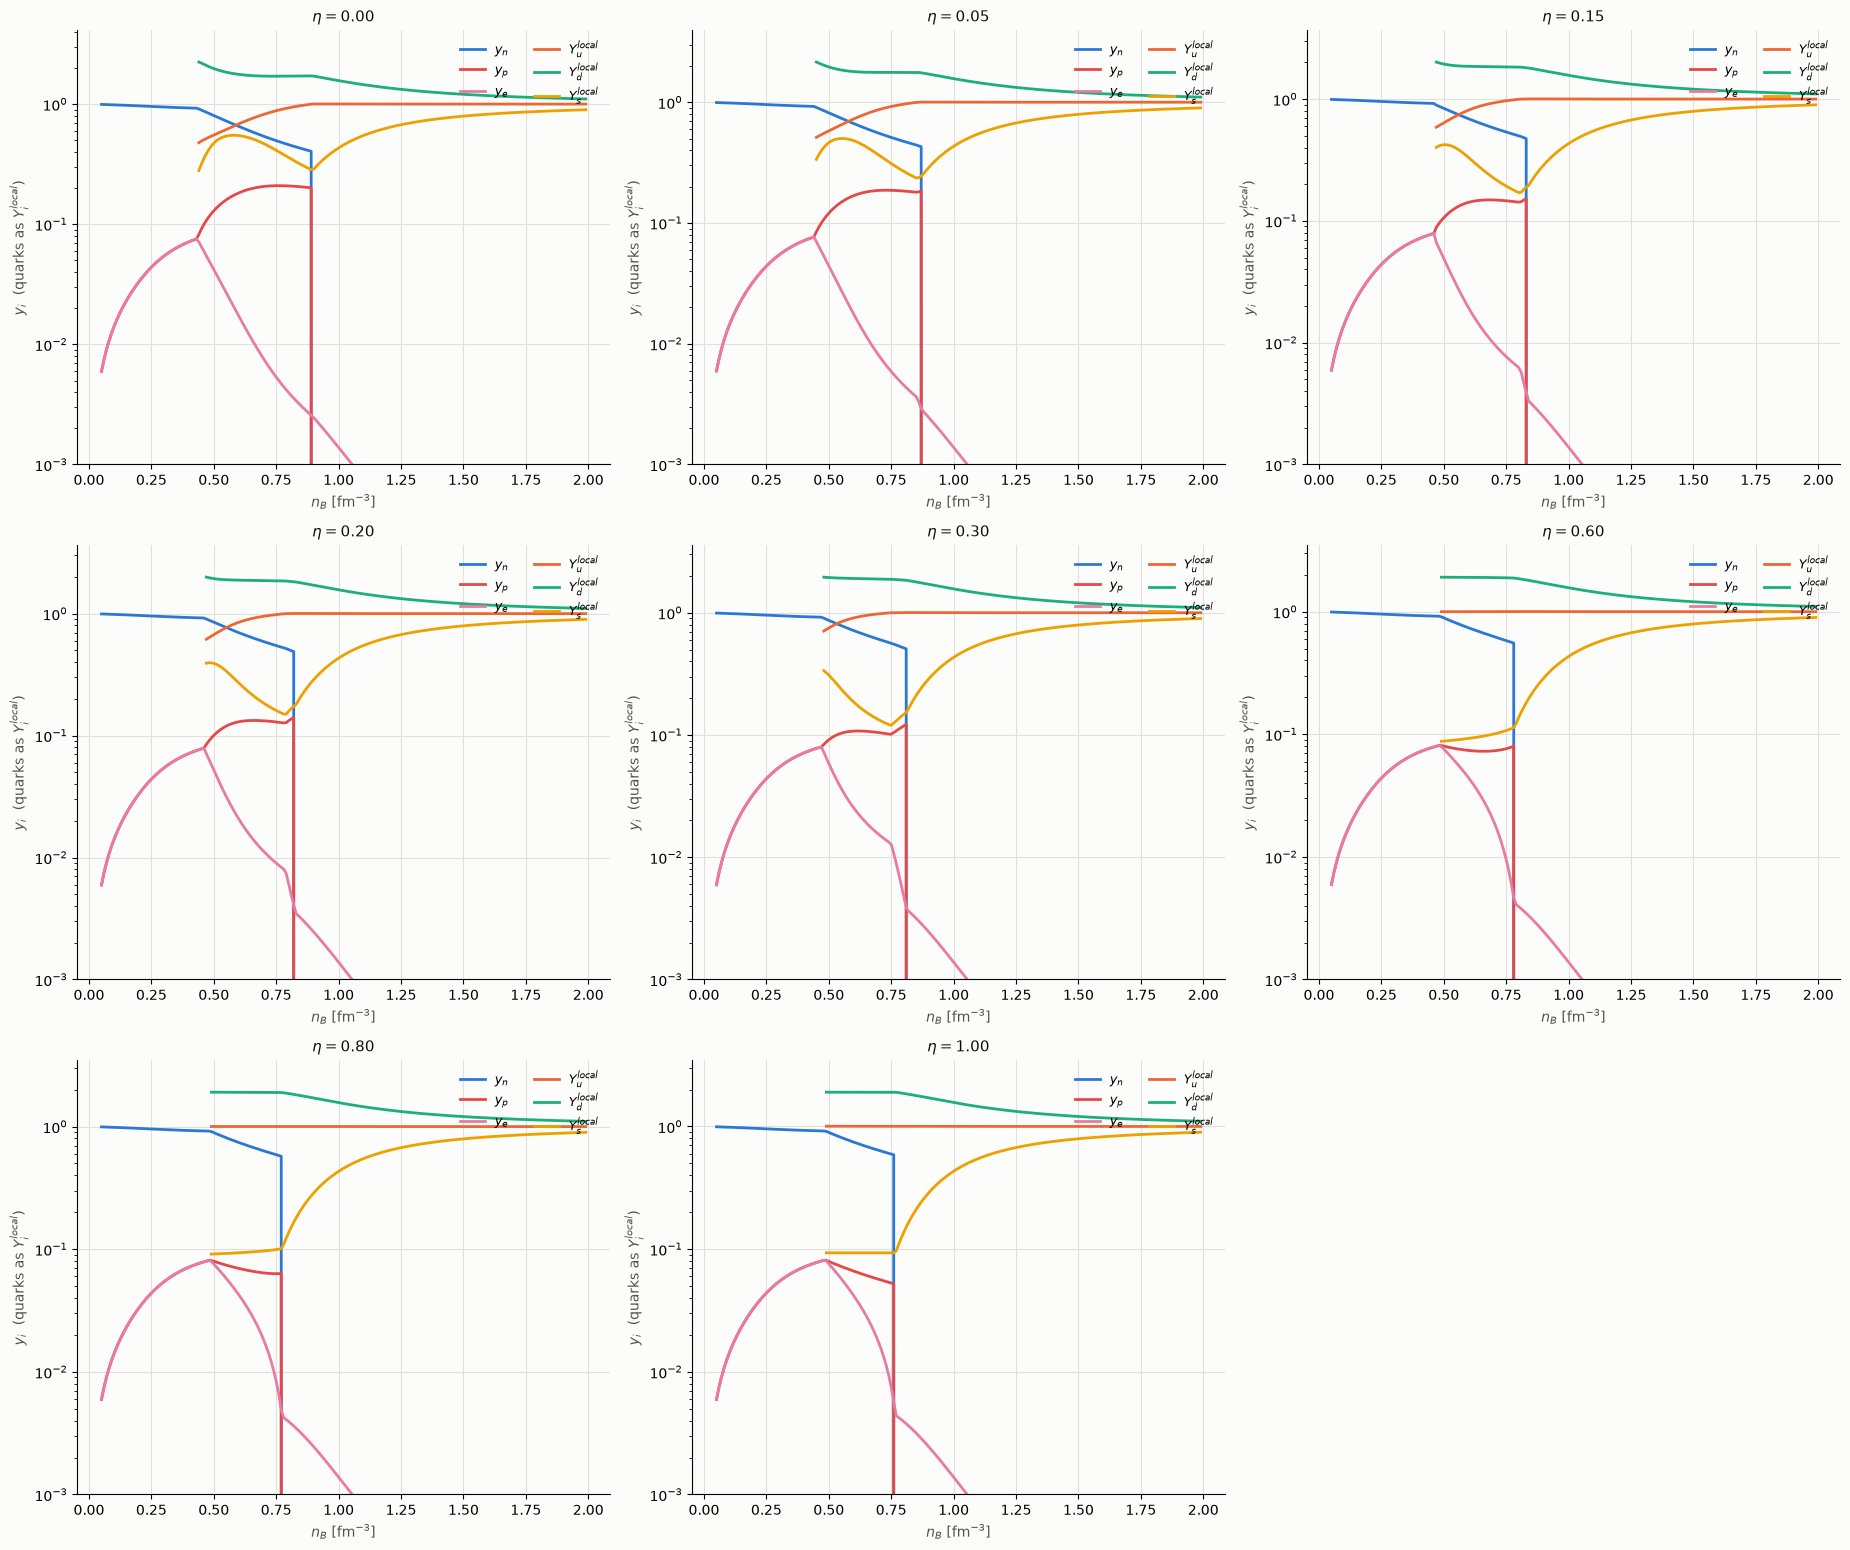

In [ ]:
species_baryon_lepton = [
    ("yn", r"$y_n$", CAT["blue"]),
    ("yp", r"$y_p$", CAT["red"]),
    ("ye", r"$y_e$", CAT["magenta"]),
]
species_quark_local = [
    ("yu", r"$Y_u^{local}$", CAT["orange"]),
    ("yd", r"$Y_d^{local}$", CAT["aqua"]),
    ("ys", r"$Y_s^{local}$", CAT["yellow"]),
]

n_eta = len(ETA_VALUES)
ncols = min(3, n_eta)
nrows = int(np.ceil(n_eta / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6.2*ncols, 5.2*nrows), squeeze=False)
fig.patch.set_facecolor(SURFACE)

for idx, eta in enumerate(ETA_VALUES):
    ax = axes[idx // ncols][idx % ncols]
    style_axes(ax)
    df_eta = results_by_eta[eta]

    for col, label, color in species_baryon_lepton:
        ax.plot(df_eta["nB"], df_eta[col], color=color, lw=2, label=label)

    quark_sum = df_eta["yu"] + df_eta["yd"] + df_eta["ys"]
    mask = quark_sum > 0
    df_q, qsum = df_eta[mask], quark_sum[mask]
    for col, label, color in species_quark_local:
        local_vals = 3 * df_q[col] / qsum
        ax.plot(df_q["nB"], local_vals, color=color, lw=2, label=label)
    ax.set_yscale('log')
    ax.set_ylim(1e-3, None)
    ax.set_title(rf"$\eta = {eta:.2f}$", color=INK, fontsize=11)
    ax.set_xlabel(r"$n_B$ [fm$^{-3}$]", color=SECONDARY)
    ax.set_ylabel(r"$y_i$  (quarks as $Y_i^{local}$)", color=SECONDARY)
    ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper right")

for idx in range(n_eta, nrows*ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.tight_layout()
plt.savefig("yi_vs_nb_all_eta.png", dpi=150, facecolor=SURFACE)
plt.show()

## 14. Colors for the eta family

`eta` is an **ordered** parameter (0 = Gibbs / global neutrality, 1 = Maxwell /
local neutrality), not a set of unrelated categories, so the overlay plots
below encode it with a single-hue ramp running light -> dark rather than with
categorical hues. Steps are taken from a blue ordinal ramp and validated
(monotone lightness, adjacent lightness gaps >= 0.06, lightest step still
clearing 2:1 against the chart surface). The same eta -> color mapping is
reused in every overlay plot, so a given shade always means the same eta.

In [ ]:
# ordinal blue ramp, light -> dark with eta
ETA_RAMP = ["#b986ef", "#e539e5", "#8925bf", "#611895", "#490d6b"]

def eta_colors(eta_values):
    """Map an arbitrary-length ordered eta list onto the ordinal ramp."""
    n = len(eta_values)
    if n == 1:
        return {eta_values[0]: ETA_RAMP[-1]}
    idx = np.linspace(0, len(ETA_RAMP) - 1, n)
    return {e: ETA_RAMP[int(round(i))] for e, i in zip(eta_values, idx)}

ETA_COLORS = eta_colors(ETA_VALUES)
print("eta -> color:", {f"{e:.2f}": c for e, c in ETA_COLORS.items()})

eta -> color: {'0.00': '#b986ef', '0.05': '#e539e5', '0.15': '#e539e5', '0.20': '#8925bf', '0.30': '#8925bf', '0.60': '#611895', '0.80': '#611895', '1.00': '#490d6b'}


## 15. Plot: mixed-phase fraction f vs n_B -- all eta on one axis

All five eta curves overlaid. Reading the family together is the point: the
mixed phase is widest at eta=0 (standard Gibbs, quark matter appears earliest
and persists to the highest density) and narrows monotonically as eta -> 1
(Maxwell), where local charge neutrality is enforced in each phase separately.

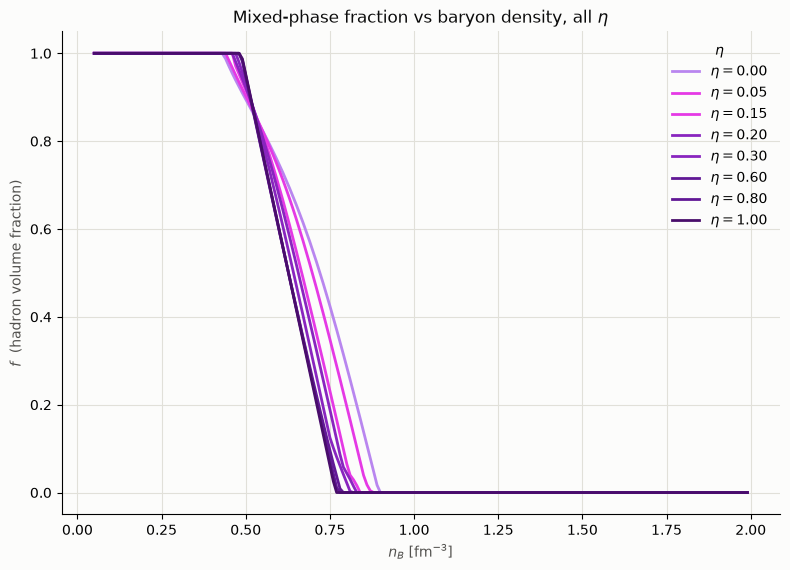

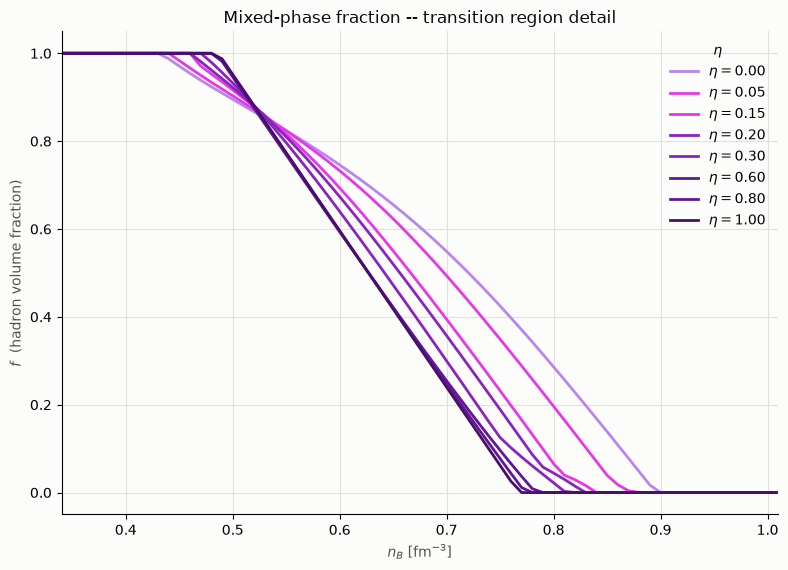

In [ ]:
def plot_f_unified(ax, xlim=None, title=""):
    style_axes(ax)
    for eta in ETA_VALUES:
        df_eta = results_by_eta[eta]
        ax.plot(df_eta["nB"], df_eta["f"], color=ETA_COLORS[eta], lw=2,
                label=rf"$\eta={eta:.2f}$")
    ax.set_xlabel(r"$n_B$ [fm$^{-3}$]", color=SECONDARY)
    ax.set_ylabel(r"$f$  (hadron volume fraction)", color=SECONDARY)
    ax.set_title(title, color=INK)
    if xlim: ax.set_xlim(*xlim)
    ax.legend(frameon=False, fontsize=10, title=r"$\eta$", title_fontsize=10)

# full density grid, exactly the range nb_values covers
fig, ax = plt.subplots(figsize=(8, 5.8))
fig.patch.set_facecolor(SURFACE)
plot_f_unified(ax, title=r"Mixed-phase fraction vs baryon density, all $\eta$")
plt.tight_layout()
plt.savefig("f_vs_nb_unified.png", dpi=150, facecolor=SURFACE)
plt.show()

# companion zoom on the transition window (f is pinned at 1 below onset and at
# 0 above it, so most of the full-range axis carries no information)
mixed_nb = [d.loc[d["phase"] == "mixed", "nB"] for d in results_by_eta.values()]
mixed_nb = [s for s in mixed_nb if len(s)]
if mixed_nb:
    lo = max(0.0, min(s.min() for s in mixed_nb) - 0.10)
    hi = max(s.max() for s in mixed_nb) + 0.12
    fig, ax = plt.subplots(figsize=(8, 5.8))
    fig.patch.set_facecolor(SURFACE)
    plot_f_unified(ax, xlim=(lo, hi),
                   title=r"Mixed-phase fraction -- transition region detail")
    plt.tight_layout()
    plt.savefig("f_vs_nb_unified_zoom.png", dpi=150, facecolor=SURFACE)
    plt.show()

## 16. Plot: unified equation of state, P vs epsilon -- all eta on one axis

The whole eta family on one set of axes. All curves share the same pure-hadron
branch at low epsilon and the same pure-quark branch at high epsilon -- eta only
controls the mixed phase in between, which is exactly what this plot makes
visible: eta=0 rises smoothly through the transition (Gibbs), while eta=1 is a
flat plateau at constant pressure (Maxwell), with the intermediate eta values
interpolating between those two limits.

The second panel zooms on the transition region, where the curves actually
separate.

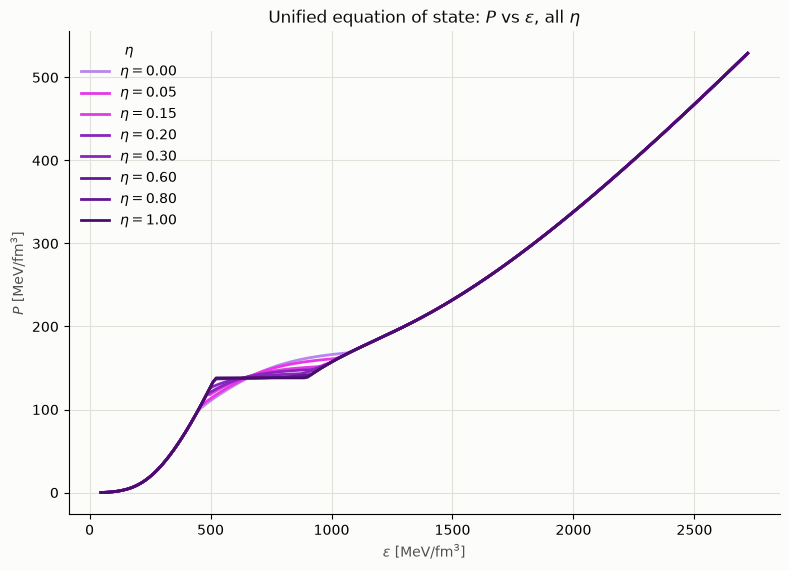

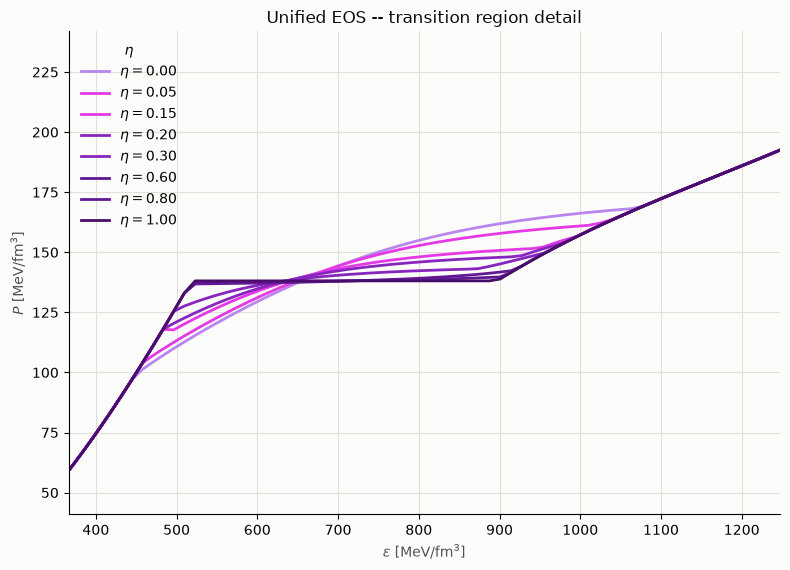

In [ ]:
def plot_unified_eos(ax, xlim=None, ylim=None, title=""):
    style_axes(ax)
    for eta in ETA_VALUES:
        df_eta = results_by_eta[eta]
        ax.plot(df_eta["eps_total"], df_eta["P_total"], color=ETA_COLORS[eta],
                lw=2, label=rf"$\eta={eta:.2f}$")
    ax.set_xlabel(r"$\epsilon$ [MeV/fm$^3$]", color=SECONDARY)
    ax.set_ylabel(r"$P$ [MeV/fm$^3$]", color=SECONDARY)
    ax.set_title(title, color=INK)
    if xlim: ax.set_xlim(*xlim)
    if ylim: ax.set_ylim(*ylim)
    ax.legend(frameon=False, fontsize=10, title=r"$\eta$", title_fontsize=10)

# full range
fig, ax = plt.subplots(figsize=(8, 5.8))
fig.patch.set_facecolor(SURFACE)
plot_unified_eos(ax, title=r"Unified equation of state: $P$ vs $\epsilon$, all $\eta$")
plt.tight_layout()
plt.savefig("P_vs_eps_unified.png", dpi=150, facecolor=SURFACE)
plt.show()

# transition-region detail, bounds derived from where the mixed phase actually sits
eps_mix, P_mix = [], []
for d in results_by_eta.values():
    dm = d[d["phase"] == "mixed"]
    if len(dm):
        eps_mix += [dm["eps_total"].min(), dm["eps_total"].max()]
        P_mix   += [dm["P_total"].min(),   dm["P_total"].max()]
fig, ax = plt.subplots(figsize=(8, 5.8))
fig.patch.set_facecolor(SURFACE)
if eps_mix:
    de, dP = max(eps_mix) - min(eps_mix), max(P_mix) - min(P_mix)
    plot_unified_eos(ax,
                     xlim=(min(eps_mix) - 0.15*de, max(eps_mix) + 0.30*de),
                     ylim=(min(P_mix)   - 0.9*dP,  max(P_mix)   + 1.1*dP),
                     title=r"Unified EOS -- transition region detail")
else:
    plot_unified_eos(ax, title=r"Unified EOS -- transition region detail")
plt.tight_layout()
plt.savefig("P_vs_eps_unified_zoom.png", dpi=150, facecolor=SURFACE)
plt.show()

## 18. Save M-R tables and plot all eta on one axis

One workbook, one sheet per eta -- same convention as the EOS output.

The left panel is the full M-R curve; the right zooms near the maximum-mass
point. The zoom earns its place here: below about 2.1 M_sun every eta curve
lies on top of every other, because a star that light never reaches the
transition density -- its whole interior is pure DD-ME2 hadronic matter, which
eta does not touch. eta only starts to matter once the core is dense enough to
enter the mixed phase, which is why the curves separate only near M_max.

In [ ]:
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# constants (CGS)
G_grav = 6.67430e-8
c_light = 2.99792458e10
solar_mass = 1.989e33

In [ ]:
def find_ns_radius(pressure, radius_array):
    """Find the stellar surface: first point where pressure drops to/below 0."""
    mask = (pressure <= 0).astype(int)
    index = np.argmax(mask)
    if index == 0:
        return radius_array[-1], len(radius_array) - 1
    return radius_array[index], index


def solve_mr_curve(p_min, p_max, pressure_to_energy_density):
    """Integrate the TOV equations over a range of central pressures for
    ONE eos (one eta), returning the M-R curve data. Logic is identical to
    the original single-eta script -- only wrapped in a function so it can
    be called once per eta."""

    def tov_equations_dimensional(r, state):
        P, m = state

        if r < 1e-5:
            r = 1e-5
        if m < 1e-6:
            m = 1e-6

        if P <= 0:
            return [0.0, 0.0]

        try:
            epsilon_val = pressure_to_energy_density(P)
        except ValueError:
            return [0.0, 0.0]

        dPdr = - (G_grav * (epsilon_val + P / c_light**2) *
                  (m + 4 * np.pi * r**3 * P / c_light**2)) / \
                (r * (r - 2 * G_grav * m / c_light**2))

        dmdr = 4 * np.pi * r**2 * epsilon_val

        return [dPdr, dmdr]

    def stop_integration_out_of_range(r, state):
        P, _ = state
        if P < p_min or P > p_max:
            return 0
        return 1
    stop_integration_out_of_range.terminal = True
    stop_integration_out_of_range.direction = -1

    r_array = np.linspace(1e-6, 20e5, 5000)
    P_central_values = np.logspace(34.5, 37.5, 80)

    M_list, R_list, central_density_list, P_list = [], [], [], []

    for P_central in P_central_values:
        try:
            central_density = pressure_to_energy_density(P_central)
        except ValueError:
            continue

        initial_conditions = [P_central, 0.0]

        sol = solve_ivp(
            tov_equations_dimensional,
            [r_array[0], r_array[-1]],
            initial_conditions,
            method='RK45',
            events=stop_integration_out_of_range,
            atol=1e-6,
            rtol=1e-6
        )

        if not sol.success:
            continue

        Pressure, Mass = sol.y
        radius_solver = sol.t

        radius_ns, index_ns = find_ns_radius(Pressure, radius_solver)

        final_radius = radius_ns / 1e5        # km
        final_mass = Mass[index_ns] / solar_mass

        R_list.append(final_radius)
        M_list.append(final_mass)
        central_density_list.append(central_density)
        P_list.append(P_central)

    return P_list, R_list, M_list, central_density_list

In [ ]:
mr_results_by_eta = {}

for eta in ETA_VALUES:
    print(f"\n=== Solving M-R curve for eta = {eta:.2f} ===")
    df_eta = results_by_eta[eta]

    pressure = df_eta["P_total"].values
    epsilo = df_eta["eps_total"].values

    # Convert to CGS
    epsilon_cgs = epsilo * 1.78266192e12        # g/cm^3
    p_cgs = pressure * 1.60218e33               # dyn/cm^2

    pressure_to_energy_density = interp1d(p_cgs, epsilon_cgs, kind="linear", bounds_error=True)

    P_list, R_list, M_list, central_density_list = solve_mr_curve(
        p_cgs.min(), p_cgs.max(), pressure_to_energy_density
    )

    central_density_MeVfm3 = np.array(central_density_list) / 1.78266192e12

    mr_df = pd.DataFrame({
        "P_central (dyn/cm^2)": P_list,
        "Radius (km)": R_list,
        "Mass (M_sun)": M_list,
        "Central Density (g/cm^3)": central_density_list,
        "Central Density (MeV/fm^3)": central_density_MeVfm3,
    })

    mr_results_by_eta[eta] = mr_df
    print(f"  -> {len(mr_df)} central pressures converged, "
          f"M_max = {mr_df['Mass (M_sun)'].max():.3f} Msun "
          f"at R = {mr_df.loc[mr_df['Mass (M_sun)'].idxmax(), 'Radius (km)']:.2f} km")

MR_OUTPUT_XLSX = "Final_MR_curve_NJLwith ddme2.xlsx"
mr_sheet_names = {eta: f"eta_{eta:.2f}" for eta in ETA_VALUES}

with pd.ExcelWriter(MR_OUTPUT_XLSX, engine="openpyxl") as writer:
    for eta, mr_df in mr_results_by_eta.items():
        mr_df.to_excel(writer, sheet_name=mr_sheet_names[eta], index=False)

print(f"\nSaved {len(mr_results_by_eta)} sheet(s) to {MR_OUTPUT_XLSX}: {list(mr_sheet_names.values())}")

NameError: name 'ETA_VALUES' is not defined

In [ ]:
# ---- dataviz palette (categorical, fixed order -- see dataviz skill) ----
CAT = {
    "blue":    "#2a78d6",
    "orange":  "#eb6834",
    "aqua":    "#1baf7a",
    "yellow":  "#eda100",
    "magenta": "#e87ba4",
    "green":   "#008300",
    "violet":  "#4a3aa7",
    "red":     "#e34948",
}
GRID, INK, SECONDARY, SURFACE = "#e1e0d9", "#0b0b0b", "#52514e", "#fcfcfb"

def style_axes(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, lw=0.8)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6))
fig.patch.set_facecolor(SURFACE)
style_axes(ax)
palette_order = list(CAT.values())
for i, eta in enumerate(ETA_VALUES):
    mr_df = mr_results_by_eta[eta]
    color = palette_order[i % len(palette_order)]
    ax.plot(mr_df["Radius (km)"], mr_df["Mass (M_sun)"], color=color, lw=2,
            marker='o', markersize=3, label=rf"$\eta = {eta:.2f}$")
ax.set_xlim(12, None)
ax.set_xlabel("Radius [km]", color=SECONDARY)
ax.set_ylabel(r"Mass [$M_\odot$]", color=SECONDARY)
ax.set_title("Mass-Radius relation (TOV), all eta", color=INK)
ax.legend(frameon=False, fontsize=10, loc="lower right")
plt.tight_layout()
plt.savefig("MR_curve_all_eta.png", dpi=150, facecolor=SURFACE)
plt.show()

NameError: name 'plt' is not defined


# 19. Adiabatic sound speed: c_ad^2

 c_ad^2 = (dP*/dnB)_(yi,f,eta) /
          (d epsilon*/dnB)_(yi,f,eta)

 The composition yi and mixed-phase fraction f are kept fixed
 while taking the numerical derivative with respect to nB.


In [ ]:


def P_eps_fixed_composition(nb, yn, yp, ys, ye, f, eta, phase):
    """
    Calculate P* and epsilon* at fixed composition (yi), f and eta.
    Only nb is varied.
    """

    if phase == "mixed":
        s = calculate_state(nb, yn, yp, ys, ye, f)

        eps = (
            f * s["epsilonN"]
            + (1.0 - f) * s["epsilonQ"]
            + f * eta * s["epsilon_eN"]
            + (1.0 - f) * eta * s["epsilon_eQ"]
            + (1.0 - eta) * s["epsilon_eG"]
        )

        P = (
            f * s["PN"]
            + (1.0 - f) * s["PQ"]
            + f * eta * s["PeN"]
            + (1.0 - f) * eta * s["PeQ"]
            + (1.0 - eta) * s["PeG"]
        )

        return P, eps

    elif phase == "hadron":
        # For the pure hadronic phase:
        # f = 1 and yn + yp = 1, ye = yp

        yn = float(yn)
        yp = float(yp)
        ye = float(ye)

        kFn = kF_hadlep(nb, yn)
        kFp = kF_hadlep(nb, yp)
        kFe = kF_hadlep(nb, ye)

        mu_n, mu_p = mu_hadronic(
            nb, yn, yp, kFn, kFp
        )
        mu_e = mu_lepton(kFe, me)

        epsN = epsilon_hadronic(
            nb, yn, yp, kFn, kFp
        )
        eps_e = epsilon_lepton(kFe, me)

        P_N = pressure_hadronic(
            nb, yn, yp, mu_n, mu_p, epsN
        )
        P_e = pressure_lepton(
            nb, ye, mu_e, eps_e
        )

        return P_N + P_e, epsN + eps_e

    elif phase == "quark":
        # For the pure quark phase:
        # f = 0

        yu, yd = calculate_fractions(
            nb, yn, yp, ys, ye, f
        )[0:2]

        kFu = kF_quark(nb, yu)
        kFd = kF_quark(nb, yd)
        kFs = kF_quark(nb, ys)

        kFe = kF_hadlep(nb, ye)

        mu_u, mu_d, mu_s = mu_quark(
            nb, yu, yd, ys, kFu, kFd, kFs
        )
        mu_e = mu_lepton(kFe, me)

        epsQ = epsilon_quark(
            nb, yu, yd, ys, kFu, kFd, kFs
        )
        eps_e = epsilon_lepton(kFe, me)

        P_Q = pressure_quark(
            nb, yu, yd, ys, kFu, kFd, kFs, epsQ
        )
        P_e = pressure_lepton(
            nb, ye, mu_e, eps_e
        )

        return P_Q + P_e, epsQ + eps_e

    return np.nan, np.nan


def calculate_cad2(df_eta, eta):
    """
    Calculate c_ad^2 for one eta.

    Numerical derivative:
        dP/dnB |_yi,f,eta
        dε/dnB |_yi,f,eta

    using a central finite difference.
    """

    cad2 = np.full(len(df_eta), np.nan)

    nb_array = df_eta["nB"].values

    for i, row in df_eta.iterrows():

        nb = row["nB"]
        phase = row["phase"]

        yn = row["yn"]
        yp = row["yp"]
        ys = row["ys"]
        ye = row["ye"]
        f  = row["f"]

        # Small density step
        dn = min(1e-4, 0.1 * nb)

        nb_plus = nb + dn
        nb_minus = max(nb - dn, 1e-8)

        try:

            P_plus, eps_plus = P_eps_fixed_composition(
                nb_plus, yn, yp, ys, ye, f, eta, phase
            )

            P_minus, eps_minus = P_eps_fixed_composition(
                nb_minus, yn, yp, ys, ye, f, eta, phase
            )

            dP_dn = (P_plus - P_minus) / (nb_plus - nb_minus)

            deps_dn = (eps_plus - eps_minus) / (nb_plus - nb_minus)

            if np.isfinite(dP_dn) and np.isfinite(deps_dn) and deps_dn != 0:
                cad2[i] = dP_dn / deps_dn

        except Exception:
            cad2[i] = np.nan

    return cad2


# ------------------------------------------------------------
# Calculate c_ad^2 for every eta
# ------------------------------------------------------------

cad2_results_by_eta = {}

for eta in ETA_VALUES:

    df_eta = results_by_eta[eta].copy()

    df_eta["c_ad2"] = calculate_cad2(
        df_eta, eta
    )

    cad2_results_by_eta[eta] = df_eta

    print(
        f"eta = {eta:.2f} : "
        f"valid c_ad^2 points = "
        f"{df_eta['c_ad2'].notna().sum()}/{len(df_eta)}"
    )

eta = 0.00 : valid c_ad^2 points = 195/195
eta = 0.05 : valid c_ad^2 points = 195/195
eta = 0.15 : valid c_ad^2 points = 195/195
eta = 0.20 : valid c_ad^2 points = 195/195
eta = 0.30 : valid c_ad^2 points = 195/195
eta = 0.60 : valid c_ad^2 points = 195/195
eta = 0.80 : valid c_ad^2 points = 195/195
eta = 1.00 : valid c_ad^2 points = 195/195



# 20. Plot c_ad^2 vs nB


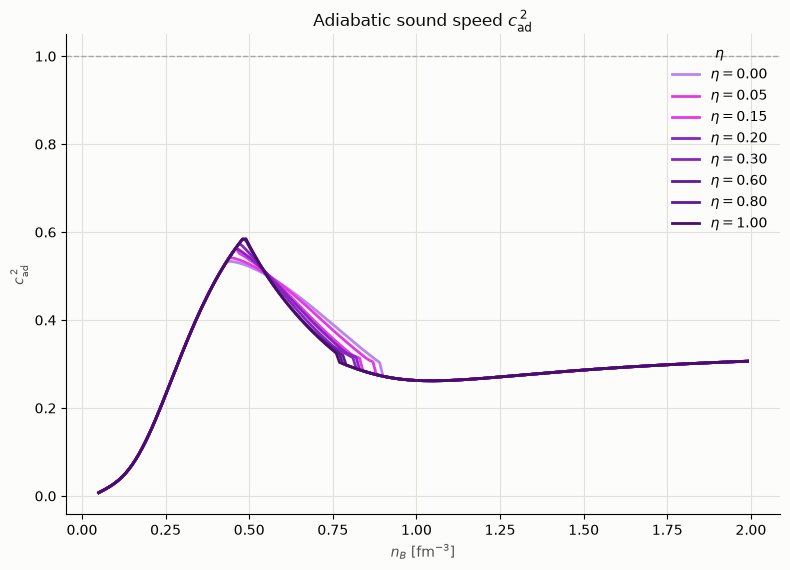

In [ ]:


fig, ax = plt.subplots(figsize=(8, 5.8))

fig.patch.set_facecolor(SURFACE)
style_axes(ax)

for eta in ETA_VALUES:

    df_eta = cad2_results_by_eta[eta]

    ax.plot(
        df_eta["nB"],
        df_eta["c_ad2"],
        color=ETA_COLORS[eta],
        lw=2,
        label=rf"$\eta={eta:.2f}$"
    )

ax.set_xlabel(r"$n_B$ [fm$^{-3}$]", color=SECONDARY)
ax.set_ylabel(r"$c_{\rm ad}^{\,2}$", color=SECONDARY)

ax.set_title(
    r"Adiabatic sound speed $c_{\rm ad}^{\,2}$",
    color=INK
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
    color="gray",
    alpha=0.6
)

ax.legend(
    frameon=False,
    fontsize=10,
    title=r"$\eta$",
    title_fontsize=10
)

plt.tight_layout()
plt.savefig(
    "c_ad2_vs_nB_all_eta.png",
    dpi=150,
    facecolor=SURFACE
)

plt.show()